In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import os 
import nibabel as nib 
import numpy as np
import matplotlib.pyplot as plt

bids_root = '/kaggle/input/brain-data/data'


In [13]:
subject_id = 'sub-BrainAge020260'
file_path = os.path.join(bids_root,subject_id,'anat',f"{subject_id}_T1w.nii",f"{subject_id}_T1w.nii")

brain_vol = nib.load(file_path)
print(brain_vol)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (130, 130, 130)
affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 130 130 130   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0

### Midlle slices


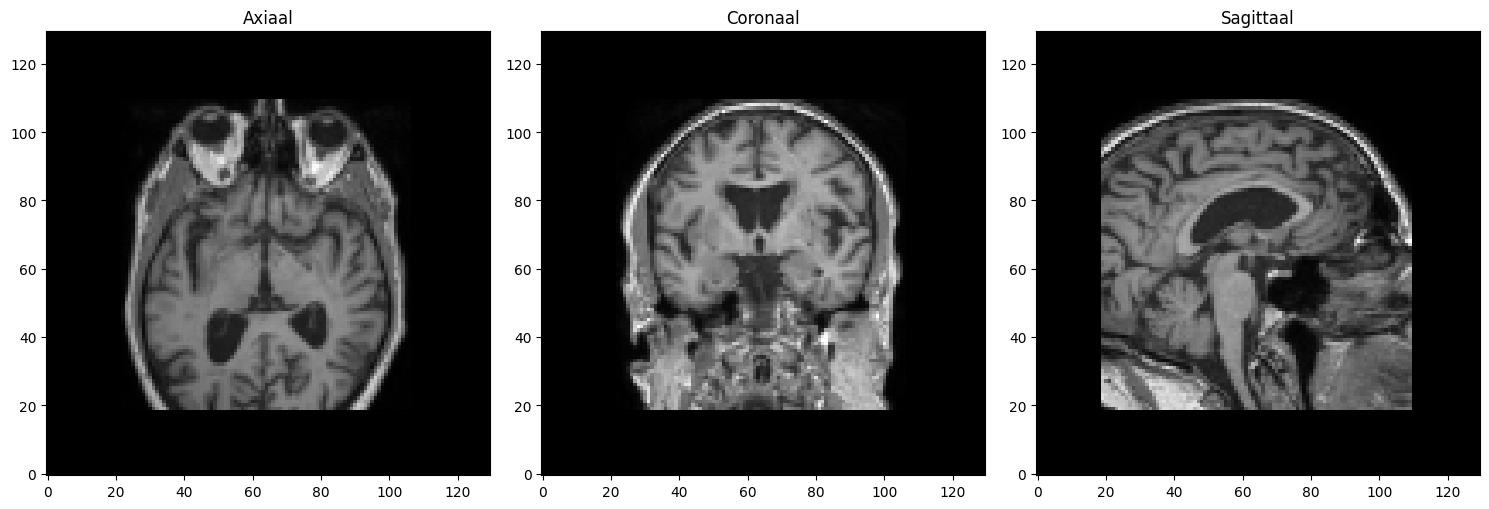

In [15]:
brain_vol_data = brain_vol.get_fdata()

axiaal_slice = brain_vol_data[:, :,int(brain_vol_data.shape[2]/2)]
coronaal_slice = brain_vol_data[:,int(brain_vol_data.shape[1]/2),:]
sagittaal_slice =brain_vol_data[int(brain_vol_data.shape[0]/2),:,:]

fig, axes = plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(axiaal_slice.T,cmap='gray',origin='lower')
axes[0].set_title('Axiaal')
axes[1].imshow(coronaal_slice.T,cmap='gray',origin='lower')
axes[1].set_title('Coronaal')
axes[2].imshow(sagittaal_slice.T,cmap='gray',origin='lower')
axes[2].set_title('Sagittaal')

plt.tight_layout()
plt.show()

### A series of Axiaal slices 

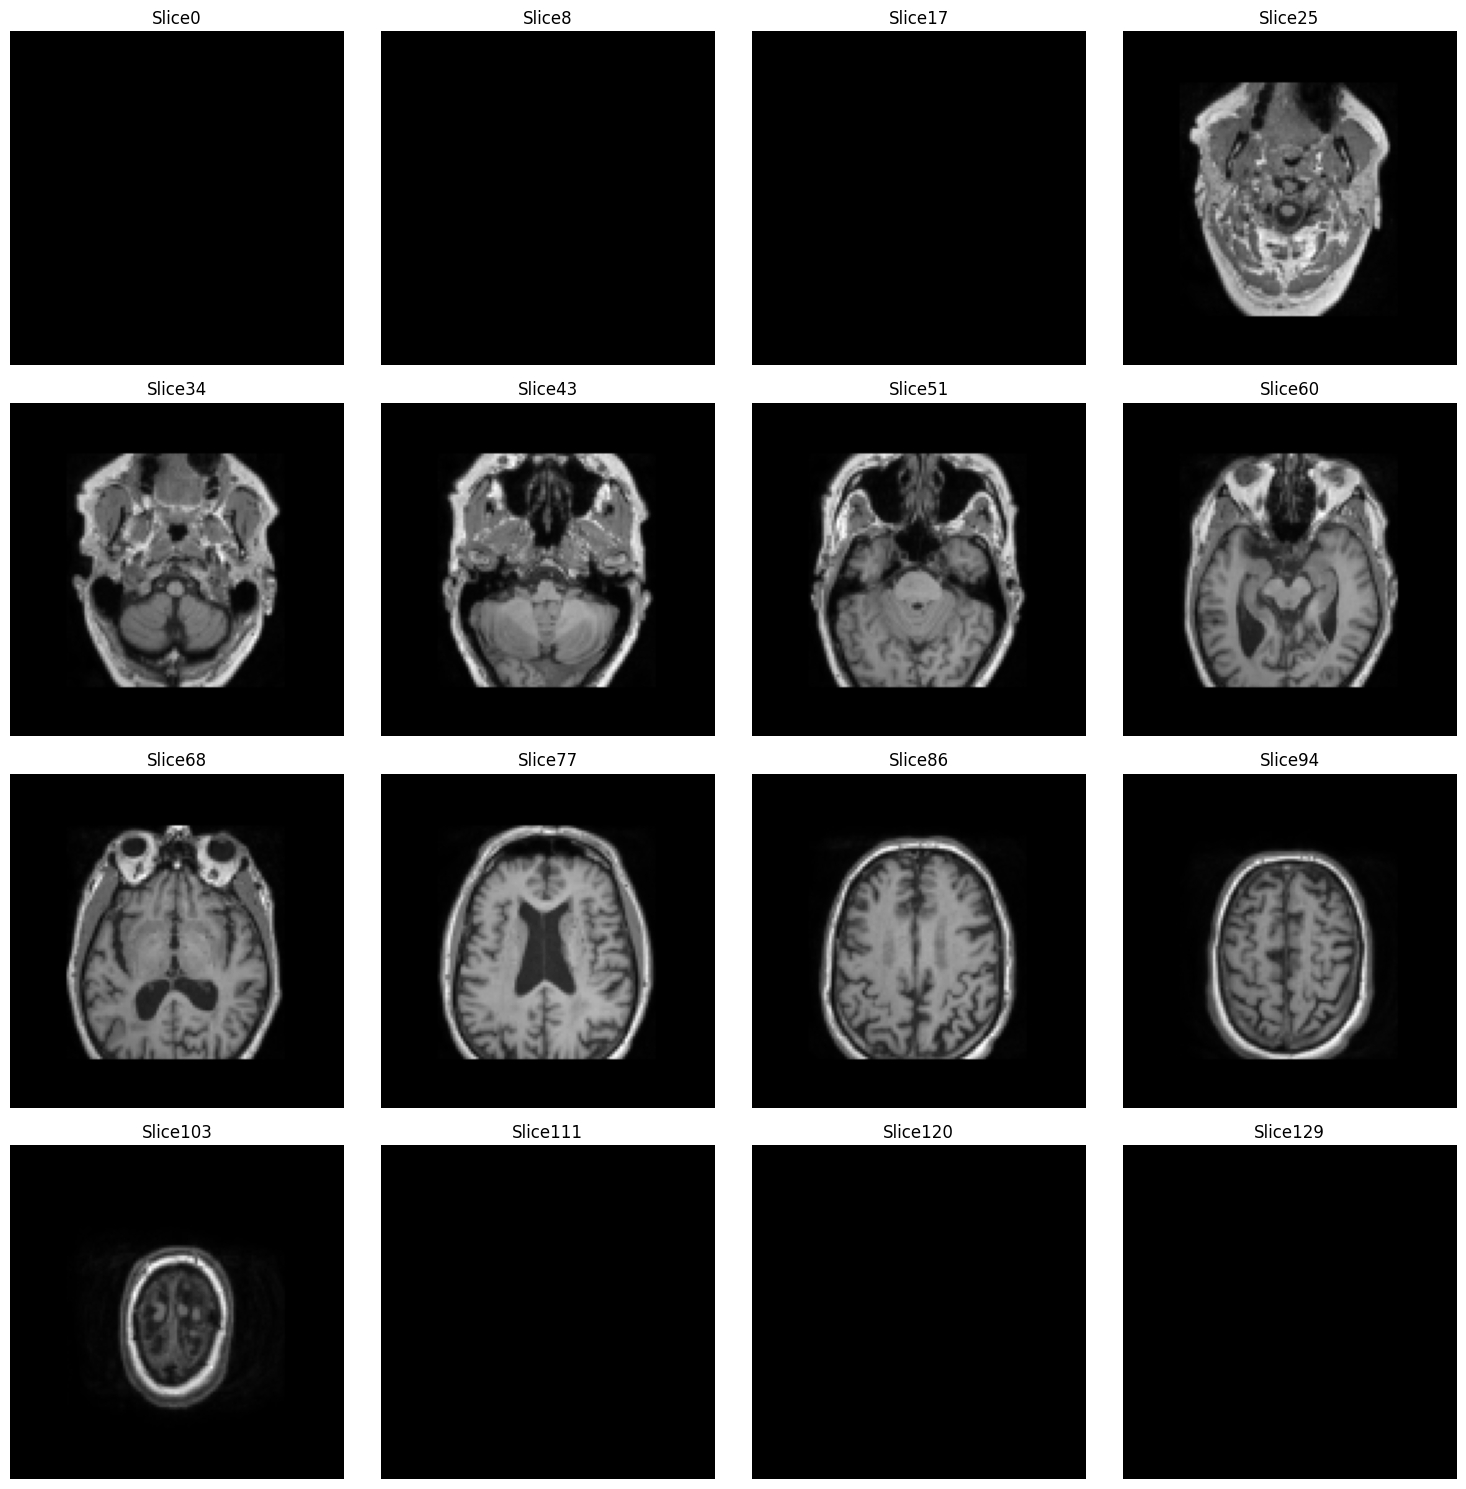

In [18]:
slices = np.linspace(0,brain_vol_data.shape[2]-1,16,dtype=int)

fig,axes = plt .subplots(4,4,figsize=(15,15))
for i, slice_idx in enumerate(slices):
    ax = axes.flat[i]
    ax.imshow(brain_vol_data[:, :, slice_idx].T,cmap='gray',origin='lower')
    ax.set_title(f'Slice{slice_idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### A series of Coronaal slices 

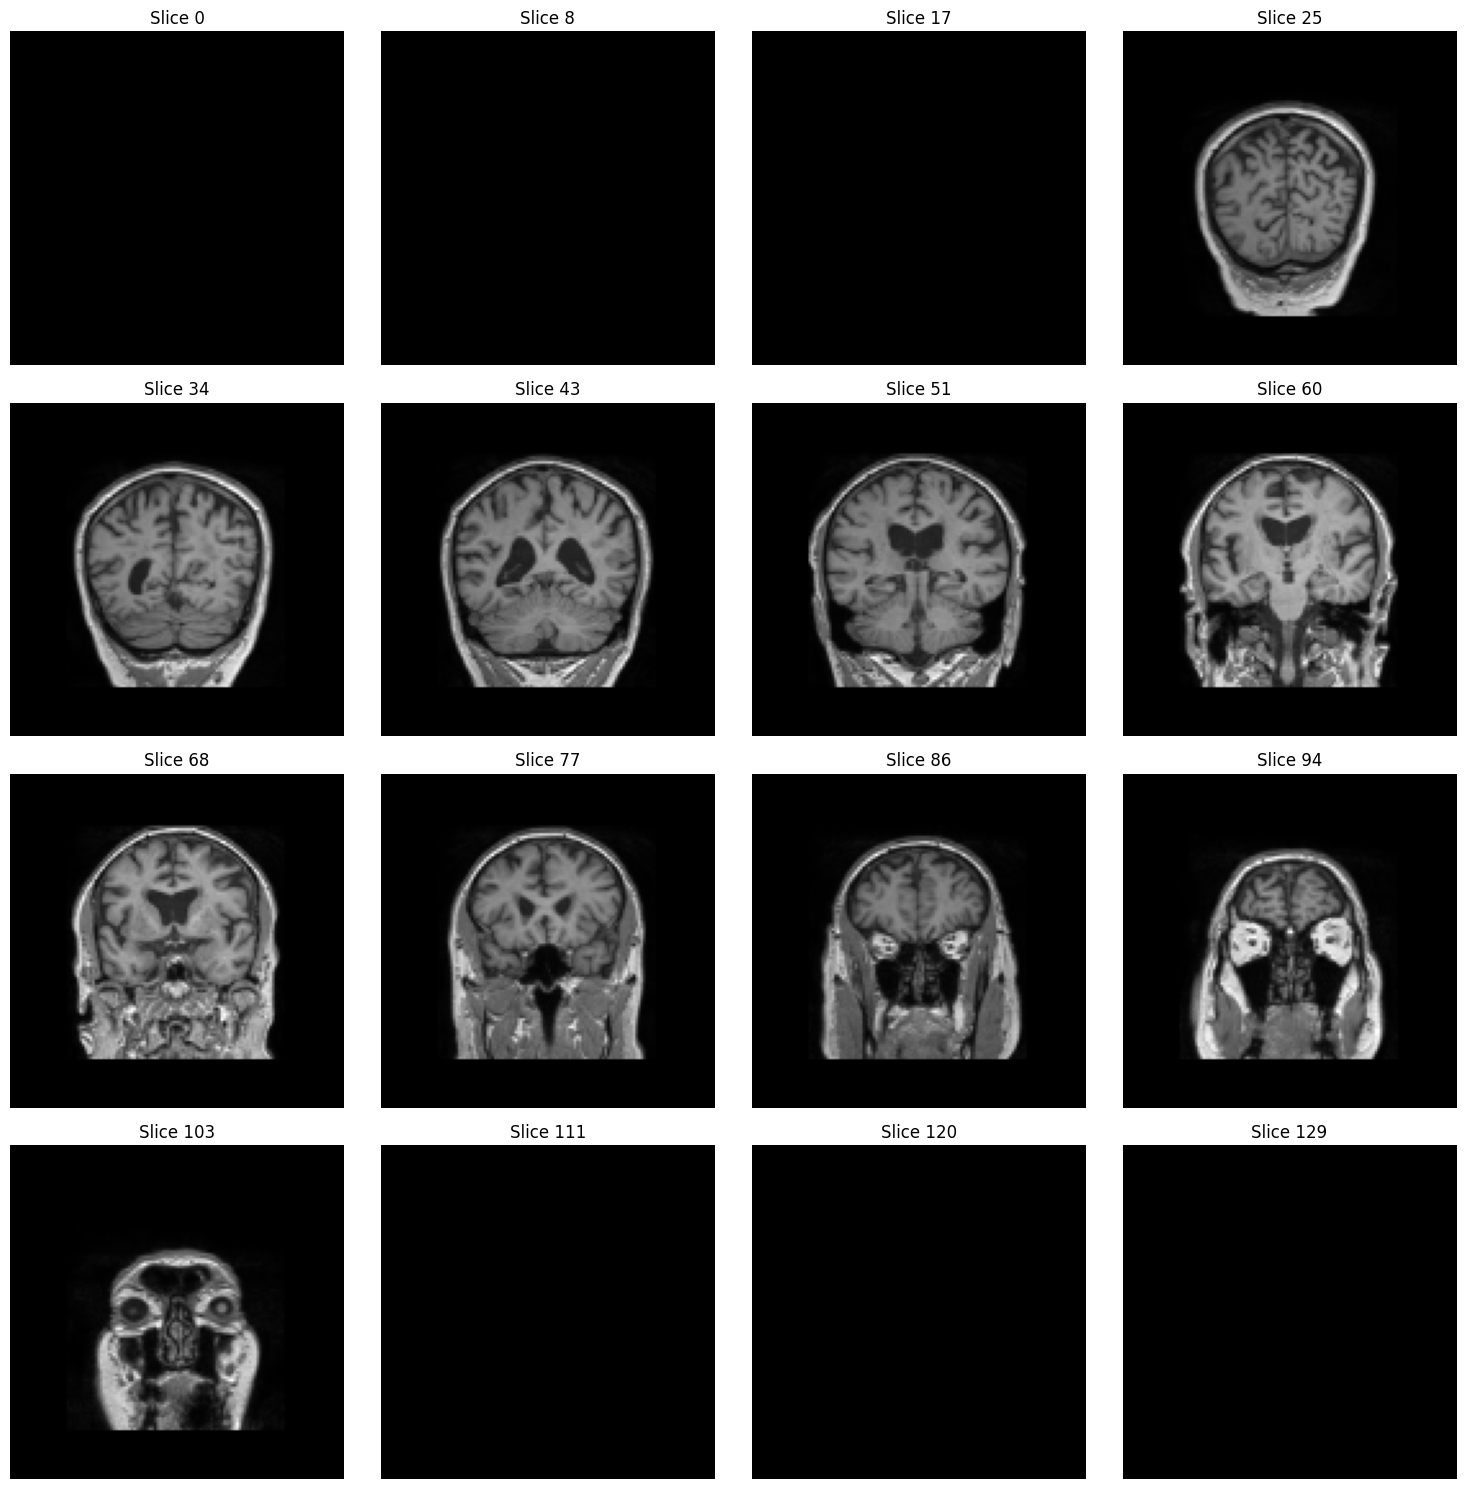

In [19]:
slices = np.linspace(0,brain_vol_data.shape[1]-1,16,dtype=int)

fig, axes = plt.subplots(4,4,figsize=(15,15))
for i,slice_idx in enumerate(slices):
    ax = axes.flat[i]
    ax.imshow(brain_vol_data[:,slice_idx,:].T,cmap='gray',origin='lower')
    ax.set_title(f'Slice {slice_idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### A series of Sagittaal slices 

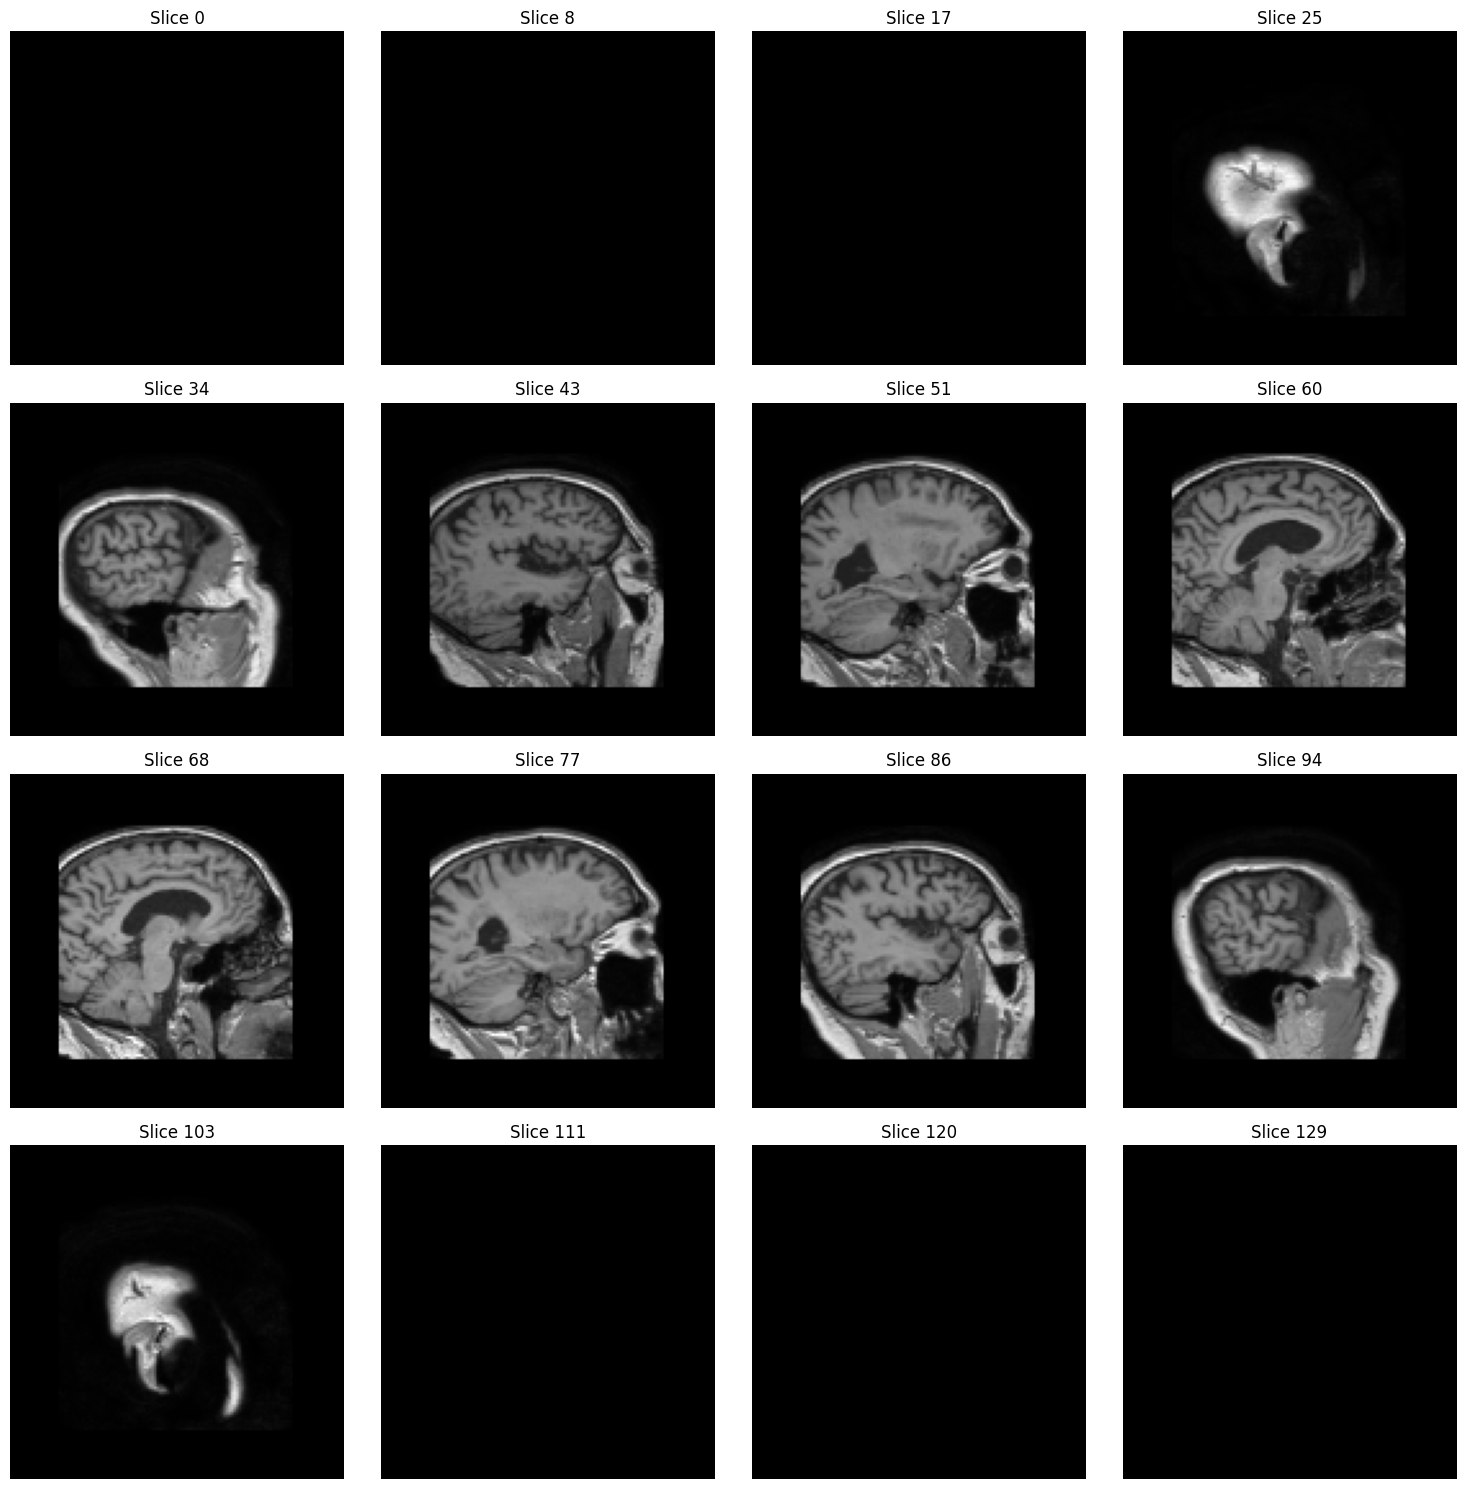

In [21]:
slices = np.linspace(0,brain_vol_data.shape[0]-1,16,dtype=int)

fig, axes = plt.subplots(4,4,figsize =(15,15))
for i , slice_idx in enumerate(slices):
    ax = axes.flat[i]
    ax.imshow(brain_vol_data[slice_idx,:,:].T,cmap='gray',origin='lower')
    ax.set_title(f'Slice {slice_idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()



### With Nilearn 


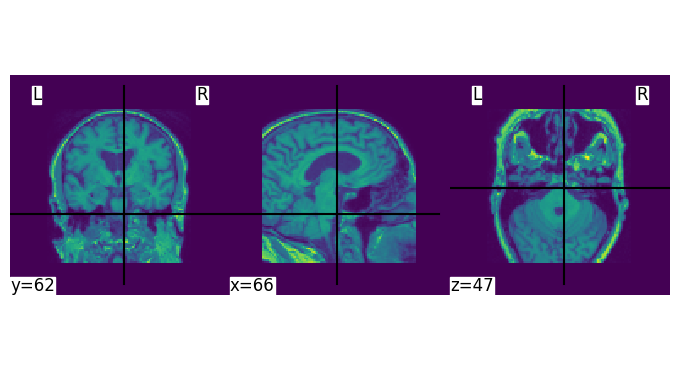

In [23]:
from nilearn import plotting 
plotting.plot_img(brain_vol)
plt.show()

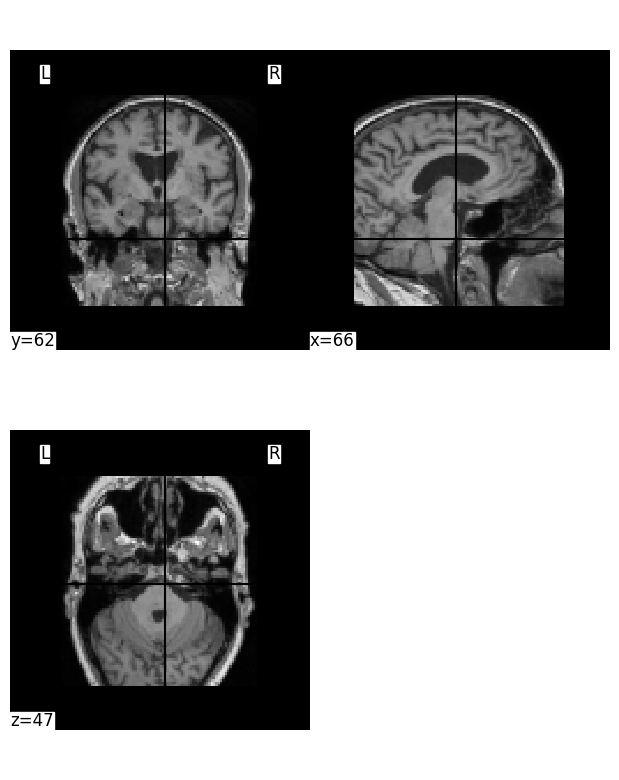

In [24]:
plotting.plot_img(brain_vol,display_mode='tiled',cmap='gray')
plt.show()

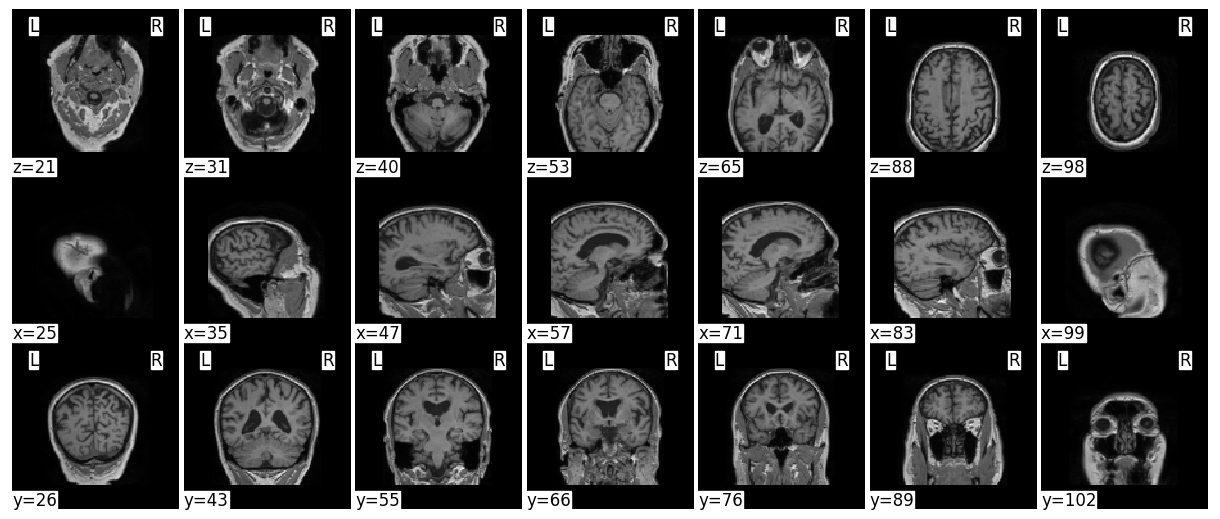

In [28]:
plotting.plot_img(brain_vol,display_mode='mosaic',cmap='gray')
plt.show()

### Preprocess


In [29]:
os.makedirs(output_dir, exist_ok=True)

NameError: name 'output_dir' is not defined

In [33]:
img_orig = nib.load("/kaggle/input/brain-data/data/sub-BrainAge020260/anat/sub-BrainAge020260_T1w.nii/sub-BrainAge020260_T1w.nii").get_fdata()
img_corr = nib.load("/kaggle/input/brain-data/data/sub-BrainAge000019/anat//sub-BrainAge020260_T1w.nii/sub-BrainAge020260_T1w_restore.nii").get_fdata()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2x3

# Axial view (Z)
axes[0, 0].imshow(img_orig[:, :, img_orig.shape[2]//2].T, cmap="gray", origin="lower")
axes[0, 0].set_title("Original Axial")
axes[1, 0].imshow(img_corr[:, :, img_corr.shape[2]//2].T, cmap="gray", origin="lower")
axes[1, 0].set_title("Bias Corrected Axial")

# Coronal view (Y)
axes[0, 1].imshow(img_orig[:, img_orig.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[0, 1].set_title("Original Coronal")
axes[1, 1].imshow(img_corr[:, img_corr.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[1, 1].set_title("Bias Corrected Coronal")

# Sagittal view (X)
axes[0, 2].imshow(img_orig[img_orig.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[0, 2].set_title("Original Sagittal")
axes[1, 2].imshow(img_corr[img_corr.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[1, 2].set_title("Bias Corrected Sagittal")

for ax in axes.flatten(): ax.axis('off')
plt.tight_layout()
plt.show()

FileNotFoundError: No such file or no access: '/kaggle/input/brain-data/data/sub-BrainAge000019/anat/sub-BrainAge020260_T1w.nii/sub-BrainAge020260_T1w_restore.nii'

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, layers, initializers
from nets.vgg3d import VGG3D


class GEN_REG(Model):
    def __init__(self, gen, reg):
        super().__init__()
        self.gen = gen
        self.reg = reg

    def __call__(self, x_in, drop_rate, training=False):
        x1 = self.gen(x_in, drop_rate, training)
        x2 = self.reg(x1, drop_rate, training)
        return x1, x2


class Discriminator(Model):
    def __init__(self, kernal_size=3, use_bn=True, padding='SAME'):
        super().__init__()

        self.dw1 = _DownSampling(64, kernal_size, 'dw1', use_bn=use_bn, padding=padding)
        self.dw2 = _DownSampling(128, kernal_size, 'dw2', use_bn=use_bn, padding=padding)
        self.dw3 = _DownSampling(256, kernal_size, 'dw3', use_bn=use_bn, padding=padding)
        self.dw4 = _DownSampling(512, kernal_size, 'dw4', use_bn=use_bn, padding=padding)

        self.conv_out = layers.Conv3D(1, kernal_size, strides=1, padding=padding, use_bias=False, name='conv_out')

    def __call__(self, x_in, drop_rate=0, training=False):
        x = self.dw1(x_in, drop_rate, training)
        x = self.dw2(x, drop_rate, training)
        x = self.dw3(x, drop_rate, training)
        x = self.dw4(x, drop_rate, training)

        x = self.conv_out(x)
        # x = tf.nn.sigmoid(x)

        return x

class Gen_encoder(Model):
    def __init__(self, kernal_size=3, use_bn=True, padding='SAME'):
        super().__init__()


        self.dw1 = _DownSampling(64, kernal_size, 'dw1', use_bn=use_bn, padding=padding) # 48
        self.dw2 = _DownSampling(128, kernal_size, 'dw2', use_bn=use_bn, padding=padding) # 24
        self.dw3 = _DownSampling(256, kernal_size, 'dw3', use_bn=use_bn, padding=padding) # 12
        self.dw4 = _DownSampling(512, kernal_size, 'dw4', use_bn=use_bn, padding=padding) # 6
        self.dw5 = _DownSampling(512, kernal_size, 'dw5', use_bn=use_bn, padding=padding) # 3
        
    @tf.function
    def __call__(self, x_in, drop_rate=0, training=False):
        x = self.dw1(x_in, drop_rate, training)
        x = self.dw2(x, drop_rate, training)
        x = self.dw3(x, drop_rate, training)
        x = self.dw4(x, drop_rate, training)
        x = self.dw5(x, drop_rate, training)

        return x

class Gen_decoder(Model):
    def __init__(self, output_channels, kernal_size=3, use_bn=True, padding='SAME'):
        super().__init__()

        self.up1 = _UpSampling(512, kernal_size, 'up1', use_bn=use_bn, padding=padding)
        self.up2 = _UpSampling(512, kernal_size, 'up2', use_bn=use_bn, padding=padding)
        self.up3 = _UpSampling(256, kernal_size, 'up3', use_bn=use_bn, padding=padding)
        self.up4 = _UpSampling(128, kernal_size, 'up4', use_bn=use_bn, padding=padding)
        self.up5 = _UpSampling(64, kernal_size, 'up5', use_bn=use_bn, padding=padding)

        self.conv_out = layers.Conv3D(output_channels, 1, padding=padding, use_bias=False, name='conv_out')

    @tf.function
    def __call__(self, x_in, drop_rate=0, training=False):

        x = self.up1(x_in, drop_rate, training)
        x = self.up2(x, drop_rate, training)
        x = self.up3(x, drop_rate, training)
        x = self.up4(x, drop_rate, training)
        x = self.up5(x, drop_rate, training)

        x = self.conv_out(x)
        x = tf.nn.relu(x)
        return x

class Generator(Model):

    def __init__(self, output_channels, kernal_size=3, use_bn=True, padding='SAME'):
        super().__init__()


        self.dw1 = _DownSampling(64, kernal_size, 'dw1', use_bn=use_bn, padding=padding) # 48
        self.dw2 = _DownSampling(128, kernal_size, 'dw2', use_bn=use_bn, padding=padding) # 24
        self.dw3 = _DownSampling(256, kernal_size, 'dw3', use_bn=use_bn, padding=padding) # 12
        self.dw4 = _DownSampling(512, kernal_size, 'dw4', use_bn=use_bn, padding=padding) # 6
        self.dw5 = _DownSampling(512, kernal_size, 'dw5', use_bn=use_bn, padding=padding) # 3
        # self.dw6 = _DownSampling(512, kernal_size, 'dw6', use_bn=use_bn, padding=padding)

        self.up1 = _UpSampling(512, kernal_size, 'up1', use_bn=use_bn, padding=padding)
        self.up2 = _UpSampling(512, kernal_size, 'up2', use_bn=use_bn, padding=padding)
        self.up3 = _UpSampling(256, kernal_size, 'up3', use_bn=use_bn, padding=padding)
        self.up4 = _UpSampling(128, kernal_size, 'up4', use_bn=use_bn, padding=padding)
        self.up5 = _UpSampling(64, kernal_size, 'up5', use_bn=use_bn, padding=padding)
        # self.up6 = _UpSampling(64, kernal_size, 'up6', use_bn=use_bn, padding=padding)
        self.conv_out = layers.Conv3D(output_channels, 1, padding=padding, use_bias=False, name='conv_out')

    @tf.function
    def __call__(self, x_in, drop_rate=0, training=False):
        x = self.dw1(x_in, drop_rate, training)
        x = self.dw2(x, drop_rate, training)
        x = self.dw3(x, drop_rate, training)
        x = self.dw4(x, drop_rate, training)
        x = self.dw5(x, drop_rate, training)
        # x = self.dw6(x, drop_rate, training)

        x = self.up1(x, drop_rate, training)
        x = self.up2(x, drop_rate, training)
        x = self.up3(x, drop_rate, training)
        x = self.up4(x, drop_rate, training)
        x = self.up5(x, drop_rate, training)
        # x = self.up6(x, drop_rate, training)

        x = self.conv_out(x)
        x = tf.nn.relu(x)
        return x

class _DownSampling(layers.Layer):

    def __init__(self, filters, kernel_size, name, pool_size=2, use_bn=True, use_res=True, padding='SAME', use_bias=True):
        super().__init__(name=name)
        self.use_bn = use_bn
        self.use_res = use_res
        stddev = np.sqrt(2/(kernel_size**2*filters))
        self.conv = layers.Conv3D(filters, kernel_size, strides=pool_size, padding=padding, use_bias=use_bias,
                                    kernel_initializer=initializers.TruncatedNormal(stddev=stddev),
                                    name='conv')
        
        if use_bn:
            self.bn = layers.BatchNormalization(momentum=0.99, name='bn')

    def __call__(self, x_in, drop_rate, training):
        # conv1
        x = self.conv(x_in)
        x = tf.nn.dropout(x, drop_rate)
        if self.use_bn:
            x = self.bn(x, training=training)
        x = tf.nn.relu(x)

        return x


class _UpSampling(layers.Layer):

    def __init__(self, filters, kernel_size, name, concat_or_add='concat', use_bn=True, padding='SAME', use_bias=True):
        super().__init__(name=name)
        self.use_bn = use_bn
        self.concat_or_add = concat_or_add
        stddev = np.sqrt(2/(kernel_size**2*filters))
        self.deconv = layers.Conv3DTranspose(filters//2, kernel_size, strides=2, padding=padding, use_bias=use_bias,
                                            kernel_initializer=initializers.TruncatedNormal(stddev=stddev),
                                            name='deconv')
        
        if use_bn:
            self.bn_deconv = layers.BatchNormalization(momentum=0.99, name='bn_deconv')

    def __call__(self, x_in, drop_rate, training):
        # deconv
        x = self.deconv(x_in)
        x = tf.nn.dropout(x, drop_rate)
        if self.use_bn:
            x = self.bn_deconv(x, training=training)
        x = tf.nn.relu(x)

        return x
